# Main paper — comparison figures

In [27]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [28]:
plt.style.use(str(Path("..") / "plot_style.mplstyle"))

In [29]:
# ---- Constants -------------------------------------------------------------

BASE = Path("..") / "comparison" / "results"
assert BASE.exists(), BASE

MOLECULE_DATASETS = ["cyp2c19_veith", "caco2_wang", "pgp_broccatelli", "ames", "lipophilicity", "sr_are"]
DNA_DATASETS = ["gue_prom_core_all", "gue_prom_300_all", "gue_emp_h3", "gue_emp_h4", "gue_mouse_0", "deeppromoter"]
PROTEIN_DATASETS = ["dbaasp_amp"]

# mmseqs2 only applies to the protein dataset (dbaasp_amp) -- excluded from the
# default method list so it doesn't eat a color slot / legend entry on
# molecule and DNA plots. Pass methods=ALL_METHODS explicitly to include it.
METHODS = ["refnd", "hestia", "datasail", "random"]
ALL_METHODS = ["refnd", "hestia", "mmseqs2", "datasail", "random"]

# Colors are assigned by position within whichever method list is in use, so
# they always come from the theme's axes.prop_cycle (plot_style.mplstyle) --
# never hardcoded.
_cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def method_colors(methods: list[str]) -> dict[str, str]:
    return {method: _cycle_colors[i % len(_cycle_colors)] for i, method in enumerate(methods)}

METHOD_COLOR = method_colors(METHODS)

# ---- Figure saving -----------------------------------------------------
# Every figure is saved as SVG; flip SAVE_PDF to also save a PDF copy
# (e.g. for camera-ready submission).
SAVE_PDF = False
FIGS_DIR = Path("..") / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str) -> None:
    fig.savefig(FIGS_DIR / f"{name}.svg")
    if SAVE_PDF:
        fig.savefig(FIGS_DIR / f"{name}.pdf")

In [30]:
# ---- Data loading helper ----------------------------------------------------

def load_summary(modality: str, dataset: str) -> dict:
    with open(BASE / modality / dataset / "summary.json") as f:
        return json.load(f)

def get_test_values(modality: str, dataset: str, method: str, head: str = "mlp") -> np.ndarray | None:
    """10-seed raw test scores for one dataset/method/head, or None if the method wasn't run on this dataset."""
    d = load_summary(modality, dataset)
    if method not in d:
        return None
    return np.array(d[method][head]["test"]["values"])

print("loader ready")

loader ready


/tmp/ipykernel_1717844/4088969891.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


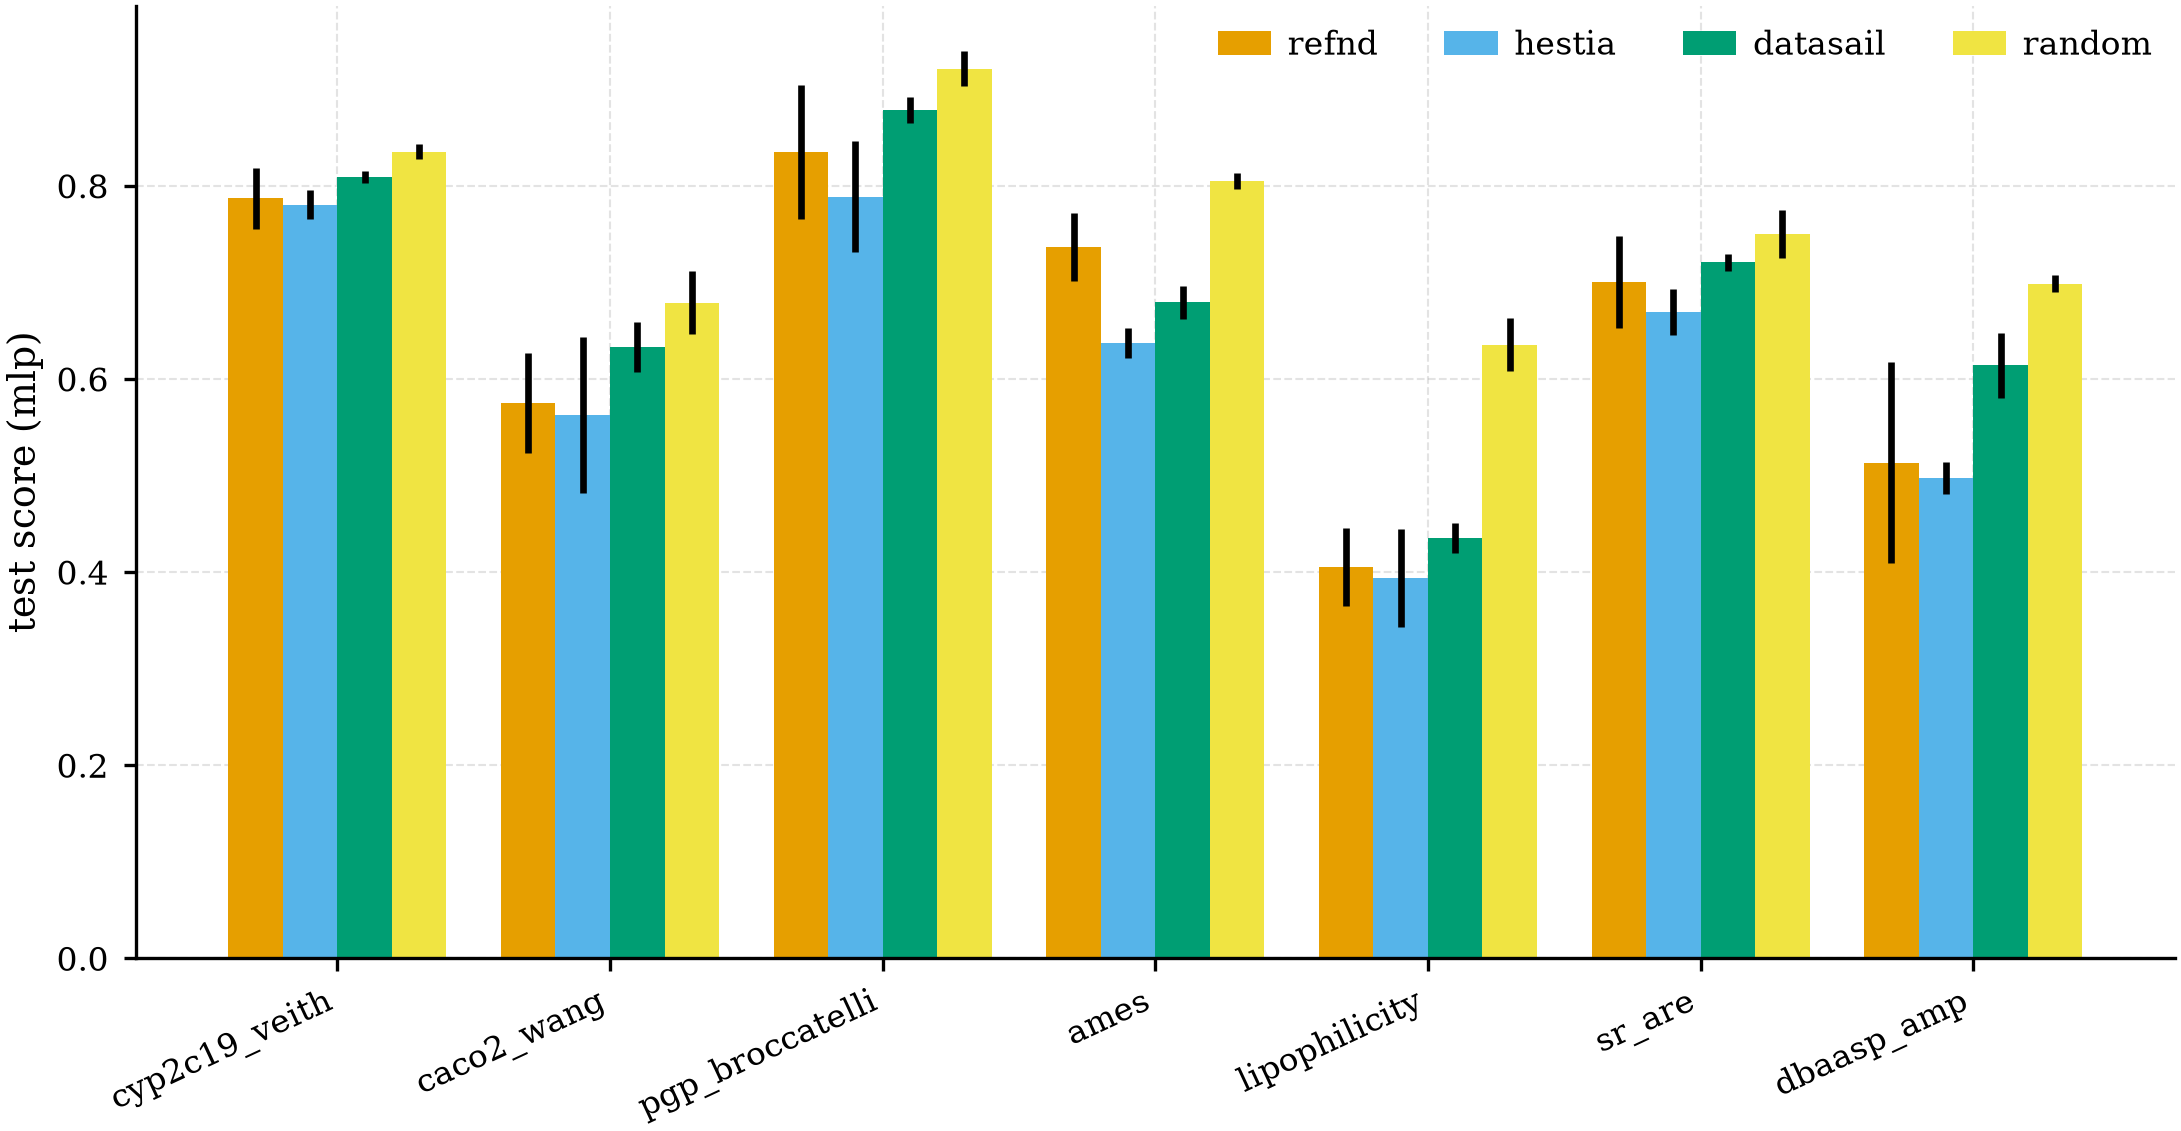

In [31]:
def plot_bar_combined(groups: list[tuple[str, str]], head: str = "mlp", methods: list[str] = METHODS):
    """groups: list of (modality, dataset) pairs, plotted left to right."""
    n_methods = len(methods)
    colors = method_colors(methods)
    x = np.arange(len(groups))
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(7.5, 4))
    for i, method in enumerate(methods):
        means, stds = [], []
        for modality, ds in groups:
            vals = get_test_values(modality, ds, method, head)
            means.append(np.nan if vals is None else vals.mean())
            stds.append(np.nan if vals is None else vals.std())
        offset = (i - (n_methods - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, label=method, color=colors[method])

    ax.set_xticks(x)
    ax.set_xticklabels([ds for _, ds in groups], rotation=25, ha="right")
    ax.set_ylabel(f"test score ({head})")
    ax.legend(ncol=n_methods)
    fig.tight_layout()
    return fig, ax

groups = [("molecule", ds) for ds in MOLECULE_DATASETS] + [("protein", ds) for ds in PROTEIN_DATASETS]
fig, ax = plot_bar_combined(groups)
plt.show()
save_fig(fig, "perf_combined_mlp")

In [32]:
# ---- Leakage / min-distance-to-train data loading ---------------------------
# comparison/results/leakage/{modality}/{dataset}/{method}_seed1.npy holds, per
# test sample, its max identity to the nearest train sample (Tanimoto for
# molecules, sequence identity for protein/DNA) -- i.e. 1 - min_distance.
# Single seed by design (see comparison/README.md).

LEAK_DIR = BASE / "leakage"
LEAK_THRESHOLD = {"molecule": 0.40, "dna": 0.40, "protein": 0.50}

def load_leakage(modality: str, dataset: str, method: str) -> np.ndarray | None:
    path = LEAK_DIR / modality / dataset / f"{method}_seed1.npy"
    if not path.exists():
        return None
    return np.load(path)

print("leakage loader ready")

leakage loader ready


In [33]:
# # ---- Draft A: ECDF of min distance to train, with threshold read-off --------

# def plot_leakage_ecdf(modality: str, dataset: str, methods: list[str] = METHODS):
#     dist_threshold = 1.0 - LEAK_THRESHOLD[modality]
#     colors = method_colors(methods)

#     fig, ax = plt.subplots(figsize=(6, 4))
#     for method in methods:
#         identity = load_leakage(modality, dataset, method)
#         if identity is None:
#             continue
#         dist = 1.0 - identity
#         x = np.sort(dist)
#         y = np.arange(1, len(x) + 1) / len(x)
#         frac_below = float((dist < dist_threshold).mean())
#         ax.plot(x, y, color=colors[method], label=f"{method} (<{dist_threshold:g}: {frac_below:.0%})")

#     ax.axvline(dist_threshold, color="black", linestyle="--", linewidth=1, alpha=0.7)
#     ax.set_xlabel("min distance to nearest train sample")
#     ax.set_ylabel("cumulative fraction of test samples")
#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 1)
#     ax.set_title(f"{modality} / {dataset} — ECDF")
#     ax.legend(fontsize=7)
#     fig.tight_layout()
#     return fig, ax

# plot_leakage_ecdf("molecule", "lipophilicity")
# plt.show()

/tmp/ipykernel_1717844/2861630636.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


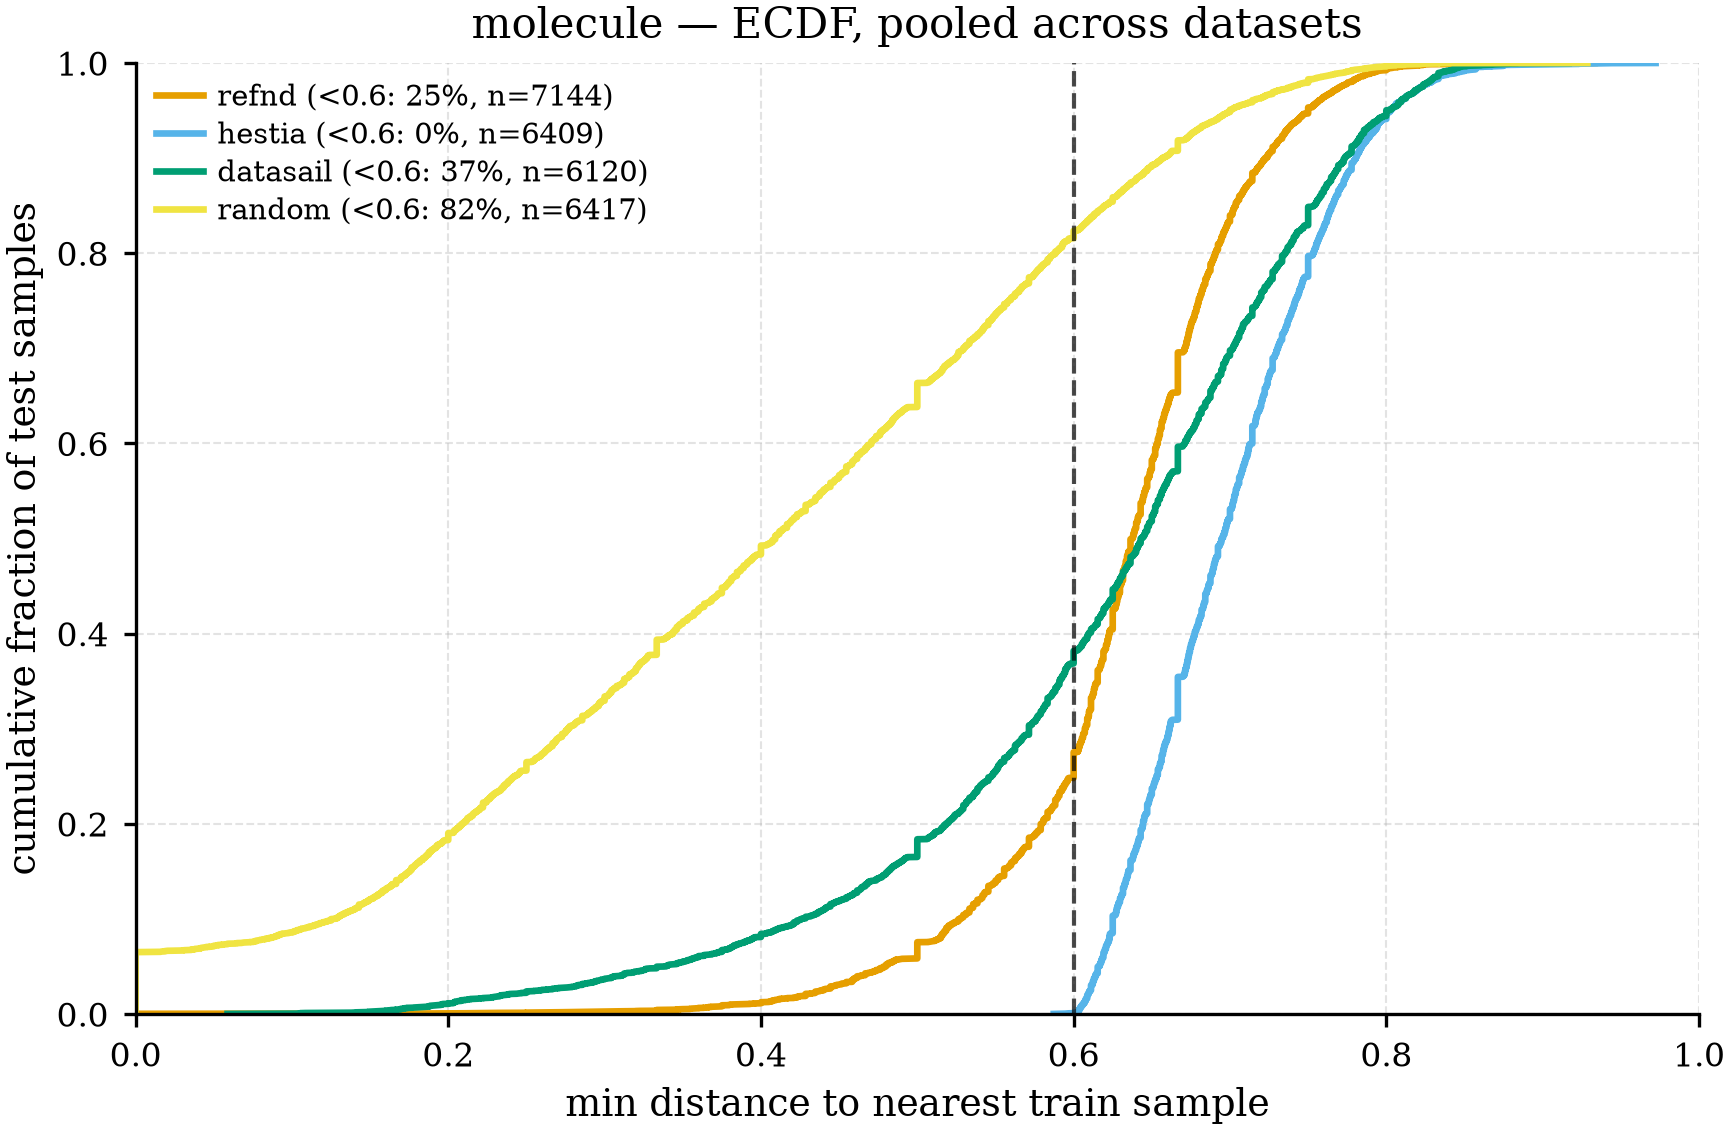

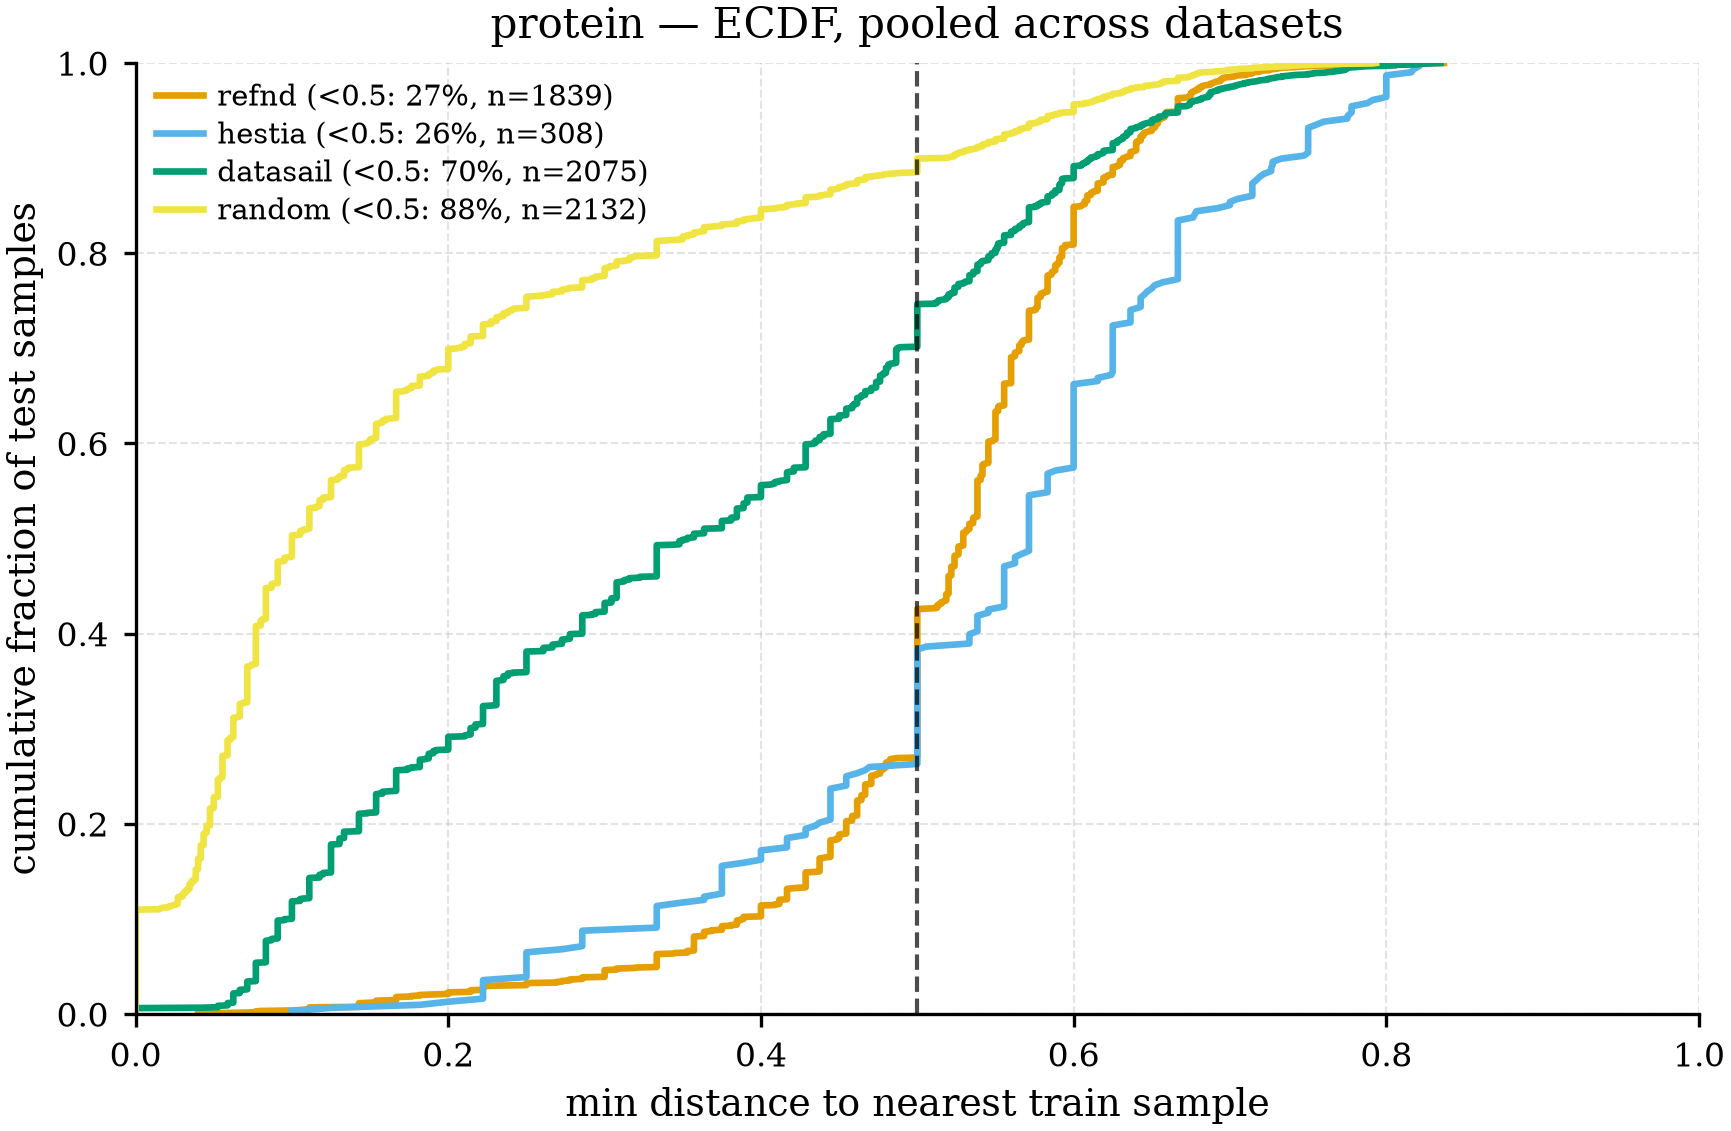

In [34]:
# ---- Draft C: ECDF combined across all datasets in a modality ---------------
# Concatenate the per-test-sample leakage arrays across every dataset of a
# modality (for each method) before computing the ECDF, so each modality gets
# a single pooled curve instead of one plot per dataset.

def plot_leakage_ecdf_combined(modality: str, datasets: list[str], methods: list[str] = METHODS):
    dist_threshold = 1.0 - LEAK_THRESHOLD[modality]
    colors = method_colors(methods)

    fig, ax = plt.subplots(figsize=(6, 4))
    for method in methods:
        pooled = []
        for dataset in datasets:
            identity = load_leakage(modality, dataset, method)
            if identity is None:
                continue
            pooled.append(identity)
        if not pooled:
            continue
        identity = np.concatenate(pooled)
        dist = 1.0 - identity
        x = np.sort(dist)
        y = np.arange(1, len(x) + 1) / len(x)
        frac_below = float((dist < dist_threshold).mean())
        ax.plot(x, y, color=colors[method], label=f"{method} (<{dist_threshold:g}: {frac_below:.0%}, n={len(x)})")

    ax.axvline(dist_threshold, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("min distance to nearest train sample")
    ax.set_ylabel("cumulative fraction of test samples")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{modality} — ECDF, pooled across datasets")
    ax.legend(fontsize=7)
    fig.tight_layout()
    return fig, ax

fig, ax = plot_leakage_ecdf_combined("molecule", MOLECULE_DATASETS)
plt.show()
save_fig(fig, "leakage_ecdf_molecule")

fig, ax = plot_leakage_ecdf_combined("protein", PROTEIN_DATASETS)
plt.show()
save_fig(fig, "leakage_ecdf_protein")

In [35]:
# ---- Runtime scaling data loading --------------------------------------------

SCALING_DIR = Path("..") / "results" / "scaling"

def load_scaling(dataset: str) -> dict[str, dict[int, float | None]]:
    """{method: {size: runtime_s or None (failed)}} for one dataset (atlas/belka)."""
    out: dict[str, dict[int, float | None]] = {}
    for path in sorted(SCALING_DIR.glob(f"runtime_{dataset}_*.json")):
        rec = json.load(open(path))[0]
        out.setdefault(rec["method"], {})[rec["size"]] = rec["runtime_s"]
    return out

for ds in ("atlas", "belka"):
    print(ds, load_scaling(ds))

atlas {'hestia': {125000: 289.006, 25000: 20.894, 3125000: None, 5000: 9.491, 625000: 8754.983}, 'refnd': {125000: 183.525, 25000: 24.089, 3125000: 6220.371, 5000: 5.687, 625000: 1017.351}}
belka {'hestia': {125000: 5977.853, 15625000: None, 25000: 192.634, 3125000: None, 625000: None}, 'refnd': {125000: 8.828, 15625000: 1106.086, 25000: 7.149, 3125000: 155.474, 625000: 30.824}}


[atlas] fit parameters (log10(y) = polyval(coeffs, log10(x))):
  refnd    linear_loglog      coeffs (high->low degree) = [1.102124285212086, -3.377091437495138]
  hestia   quadratic_loglog   coeffs (high->low degree) = [0.5826515707097086, -4.096403020758745, 8.134838579654296]


/tmp/ipykernel_1717844/823548562.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


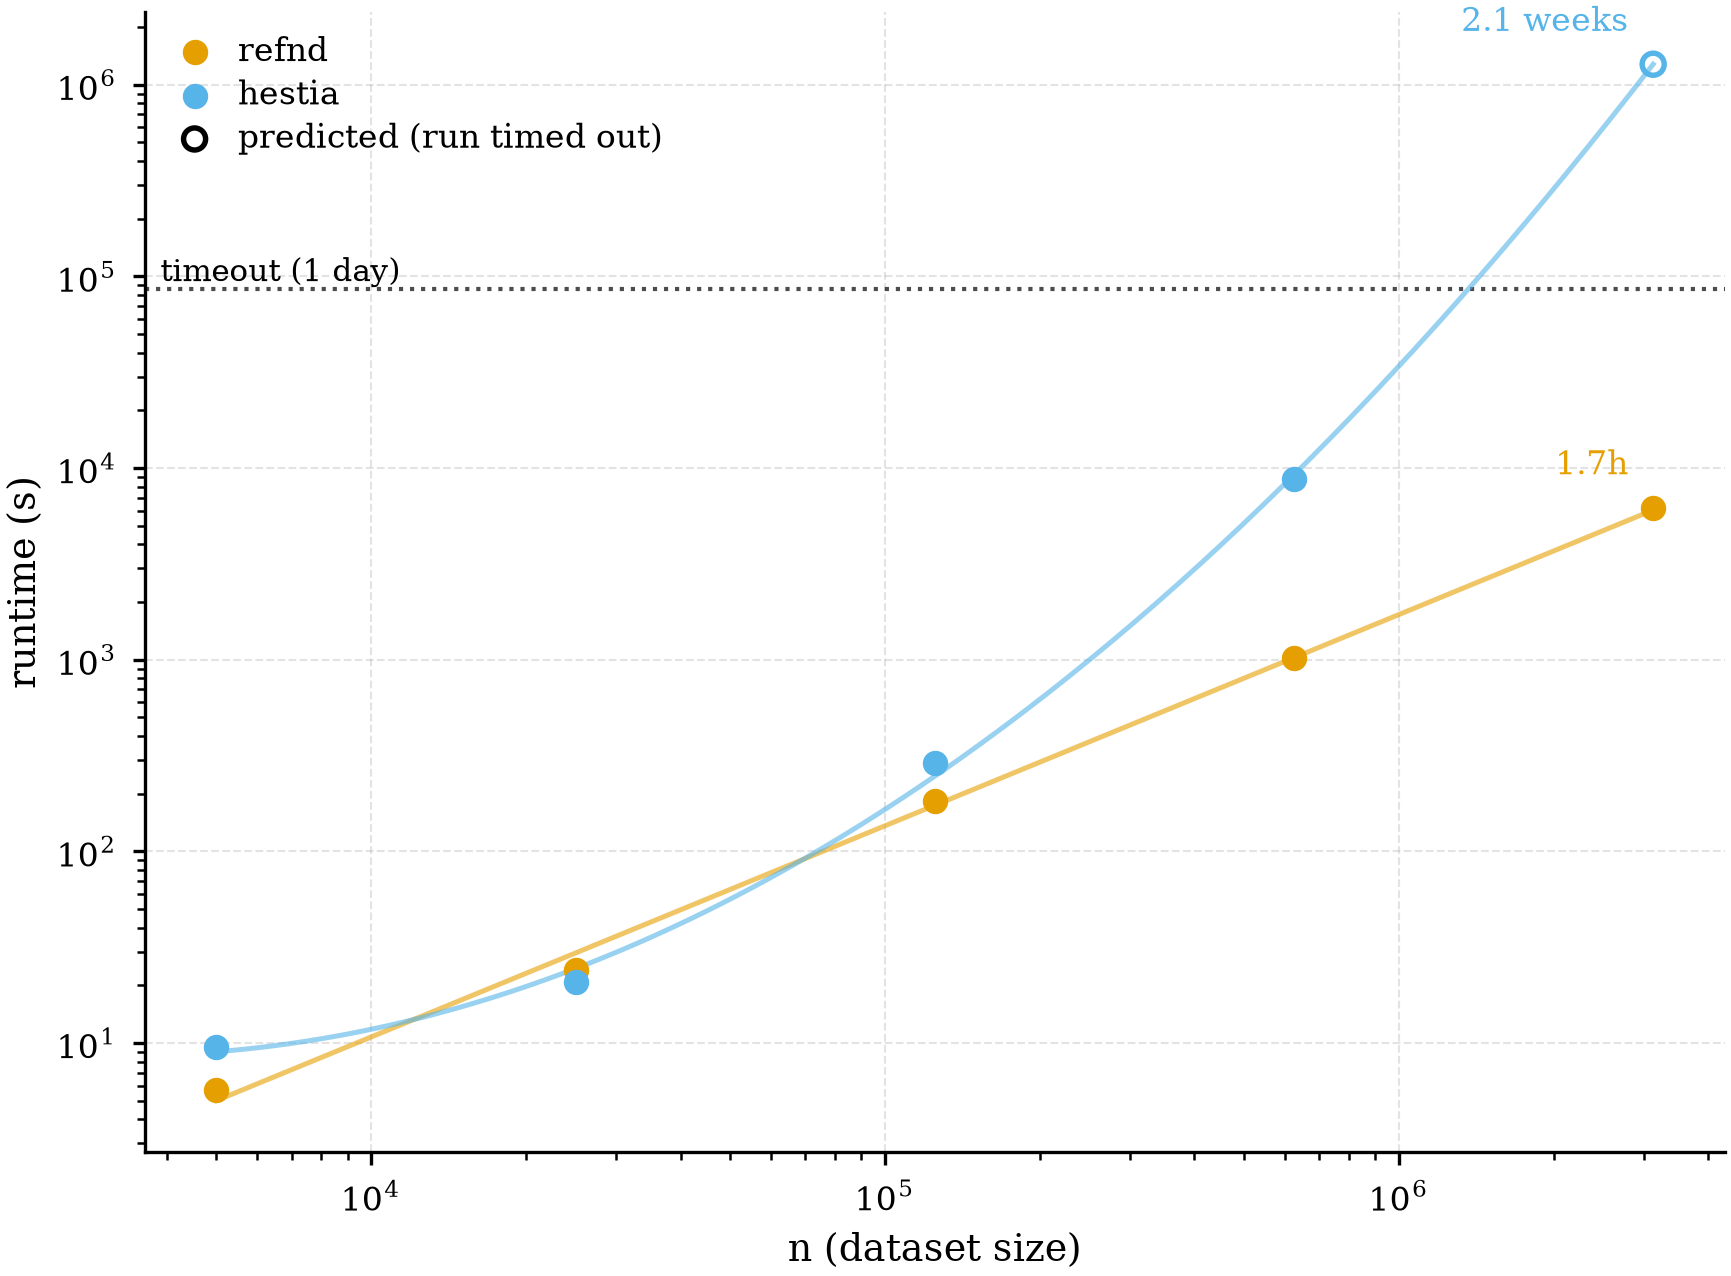

/tmp/ipykernel_1717844/823548562.py:30: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(log_x, log_y, degree)


[belka] fit parameters (log10(y) = polyval(coeffs, log10(x))):
  refnd    quadratic_loglog   coeffs (high->low degree) = [0.2457328689223723, -2.0437376750730785, 5.055323100492477]
  hestia   quadratic_loglog   coeffs (high->low degree) = [0.2014437886055619, 0.2216223095169953, -2.586249523702329]


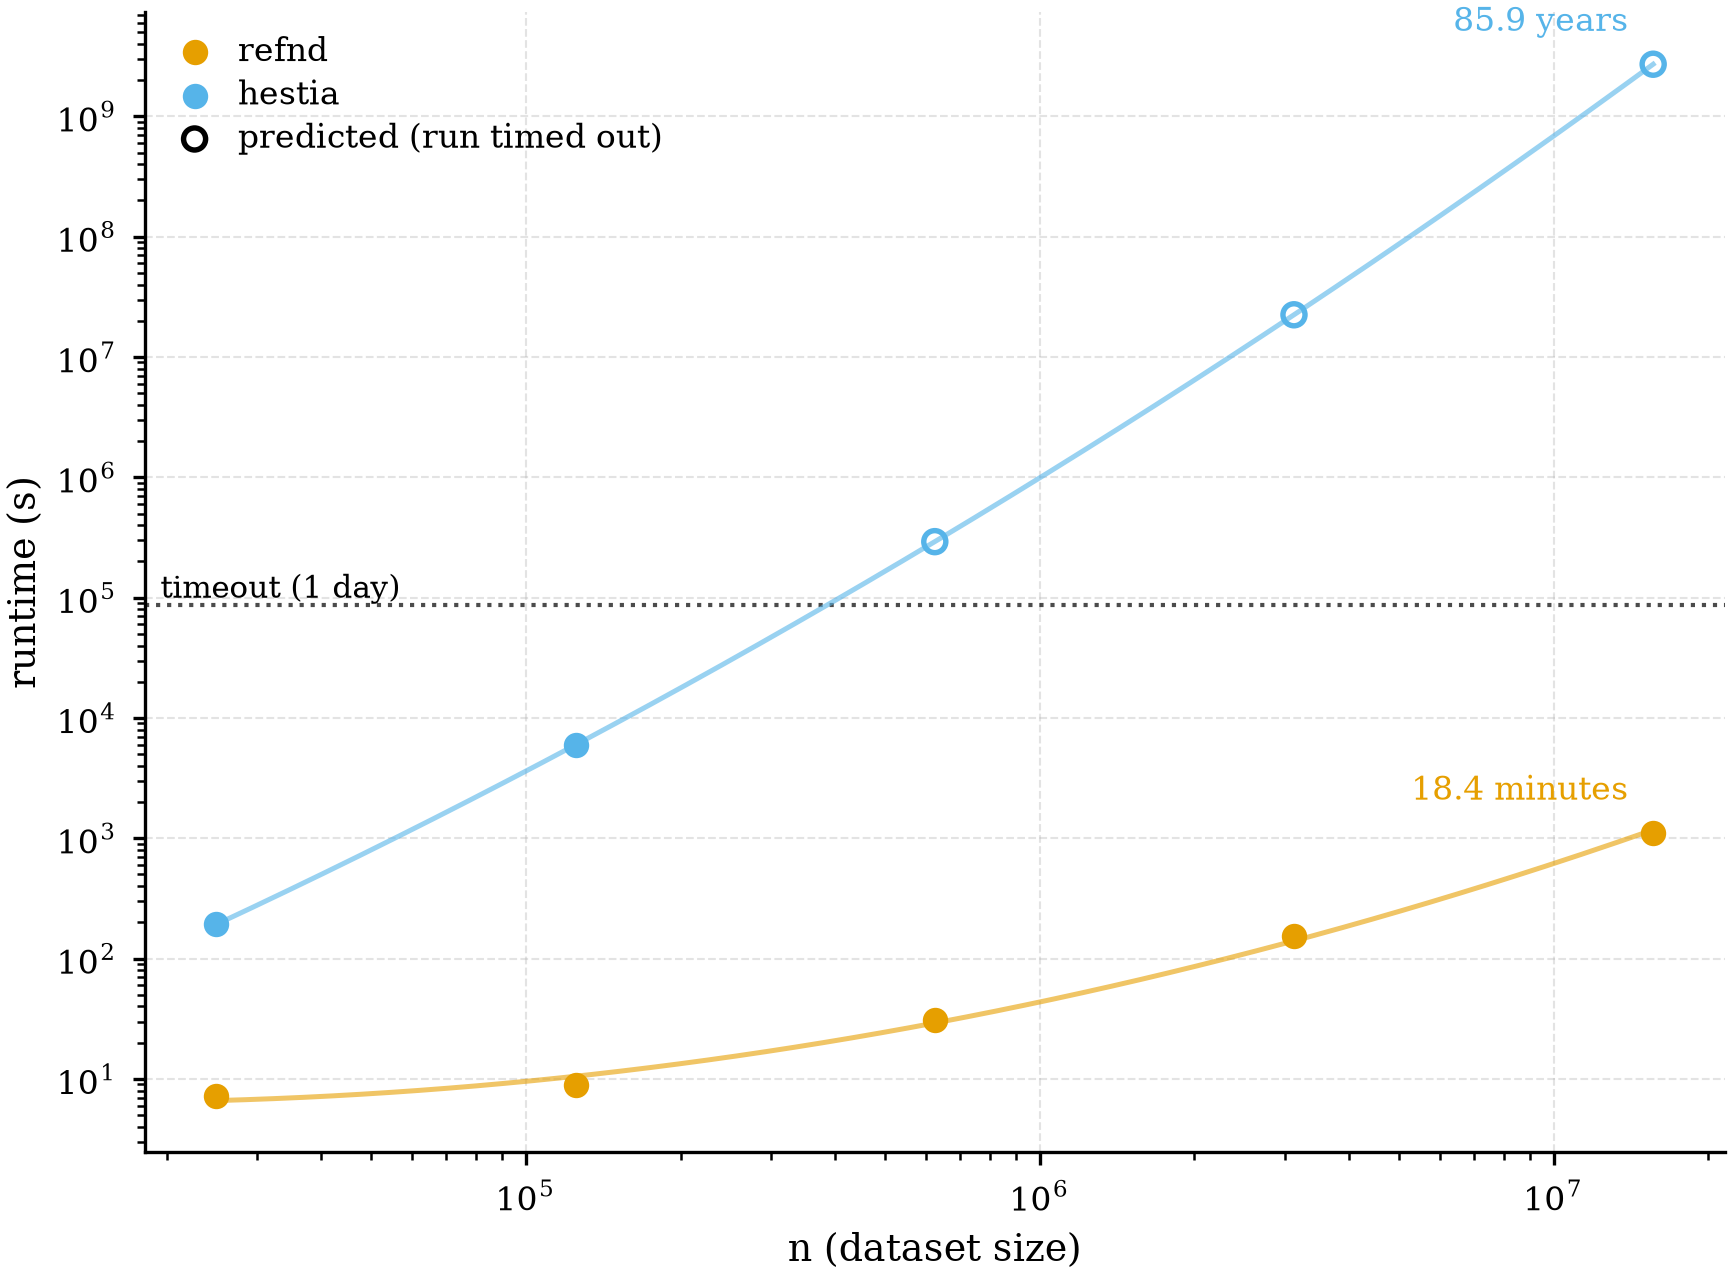

In [36]:
# ---- Runtime scaling: model fit per (dataset, method), hollow = predicted/timed out --
# hestia: quadratic in log-log space on both datasets (worse-than-n*log(n) clustering cost).
# refnd:  linear (power law) on atlas -- build_s dominates there and fits a straight
#         line almost perfectly (R^2=0.998); quadratic on belka -- at belka's much
#         larger sizes, leiden_s's share of total runtime (which grows faster than
#         build_s's share, per the per-stage breakdown) becomes large enough to bend
#         the curve.

FIT_KIND = {
    ("atlas", "refnd"): "linear_loglog", ("atlas", "hestia"): "quadratic_loglog",
    ("belka", "refnd"): "quadratic_loglog", ("belka", "hestia"): "quadratic_loglog",
}
TIMEOUT_S = 24 * 3600  # 1 day

# Fixed display unit for the rightmost-point annotation, per (dataset, method) --
# chosen so the number reads naturally at that method's scale on that dataset;
# falls back to auto (days/hours) when not listed.
ANNOTATION_UNIT = {
    ("atlas", "hestia"): "weeks",
    ("belka", "hestia"): "years",
    ("belka", "refnd"): "minutes",
}
_SECONDS_PER_UNIT = {"minutes": 60, "hours": 3600, "days": 86400, "weeks": 7 * 86400, "years": 365.25 * 86400}

def _fit_predict(kind: str, sizes_ok: list[int], runtimes_ok: list[float]):
    x = np.array(sizes_ok, dtype=float)
    y = np.array(runtimes_ok, dtype=float)
    log_x, log_y = np.log10(x), np.log10(y)
    degree = {"linear_loglog": 1, "quadratic_loglog": 2}[kind]
    coeffs = np.polyfit(log_x, log_y, degree)
    predict = lambda xs: 10 ** np.polyval(coeffs, np.log10(xs))
    return predict, coeffs


def _format_duration(seconds: float, unit: str | None = None) -> str:
    if unit is not None:
        return f"{seconds / _SECONDS_PER_UNIT[unit]:.1f} {unit}"
    days = seconds / 86400
    if days >= 1:
        return f"{days:.1f}d"
    hours = seconds / 3600
    return f"{hours:.1f}h"


def plot_scaling(dataset: str, methods: list[str] = ("refnd", "hestia")):
    data = load_scaling(dataset)
    colors = method_colors(list(methods))
    fit_params = {}

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.set_xscale("log")
    ax.set_yscale("log")

    for method in methods:
        sizes_all = sorted(data.get(method, {}))
        if not sizes_all:
            continue
        sizes_ok = [s for s in sizes_all if data[method][s] is not None]
        runtimes_ok = [data[method][s] for s in sizes_ok]

        kind = FIT_KIND[(dataset, method)]
        predict, coeffs = _fit_predict(kind, sizes_ok, runtimes_ok)
        fit_params[method] = {"kind": kind, "coeffs": coeffs.tolist()}

        # observed points: solid markers
        ax.scatter(sizes_ok, runtimes_ok, color=colors[method], s=28, zorder=3, label=method)

        # fit curve across the full observed size range
        x_fit = np.logspace(np.log10(min(sizes_all)), np.log10(max(sizes_all)), 200)
        ax.plot(x_fit, predict(x_fit), color=colors[method], linewidth=1.2, alpha=0.6, zorder=2)

        # timed-out sizes: hollow marker at the fit-predicted runtime
        sizes_missing = [s for s in sizes_all if data[method][s] is None]
        if sizes_missing:
            y_pred = predict(np.array(sizes_missing, dtype=float))
            ax.scatter(sizes_missing, y_pred, facecolors="none", edgecolors=colors[method],
                      s=28, linewidths=1.3, zorder=3)

        # annotate the rightmost (largest-n) point, real or predicted, with its runtime
        rightmost_size = sizes_all[-1]
        rightmost_y = data[method][rightmost_size]
        if rightmost_y is None:
            rightmost_y = float(predict(np.array([rightmost_size]))[0])
        unit = ANNOTATION_UNIT.get((dataset, method))
        ax.annotate(_format_duration(rightmost_y, unit), (rightmost_size, rightmost_y),
                   textcoords="offset points", xytext=(-6, 8), ha="right", fontsize=8,
                   color=colors[method])

    ax.axhline(TIMEOUT_S, color="black", linestyle=":", linewidth=1, alpha=0.7, zorder=1)
    ax.text(0.01, TIMEOUT_S, "timeout (1 day)", transform=ax.get_yaxis_transform(),
           fontsize=7.5, va="bottom", ha="left")

    # legend entry for the hollow-marker convention
    ax.scatter([], [], facecolors="none", edgecolors="black", s=28, linewidths=1.3,
              label="predicted (run timed out)")

    ax.set_xlabel("n (dataset size)")
    ax.set_ylabel("runtime (s)")
    ax.legend(fontsize=8)
    fig.tight_layout()

    print(f"[{dataset}] fit parameters (log10(y) = polyval(coeffs, log10(x))):")
    for method, p in fit_params.items():
        print(f"  {method:8s} {p['kind']:18s} coeffs (high->low degree) = {p['coeffs']}")

    return fig, ax, fit_params

fig, ax, fit_params = plot_scaling("atlas")
plt.show()
save_fig(fig, "scaling_atlas")

fig, ax, fit_params = plot_scaling("belka")
plt.show()
save_fig(fig, "scaling_belka")

In [37]:
# ---- Table: linear vs quadratic (log-log) fit R^2, per method x dataset -----

def _loglog_r2(sizes_ok: list[int], runtimes_ok: list[float], degree: int) -> float:
    log_x = np.log10(sizes_ok)
    log_y = np.log10(runtimes_ok)
    coeffs = np.polyfit(log_x, log_y, degree)
    pred = np.polyval(coeffs, log_x)
    ss_res = np.sum((log_y - pred) ** 2)
    ss_tot = np.sum((log_y - log_y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

rows = []
for dataset in ("atlas", "belka"):
    data = load_scaling(dataset)
    for method in ("refnd", "hestia"):
        sizes_all = sorted(data.get(method, {}))
        sizes_ok = [s for s in sizes_all if data[method][s] is not None]
        runtimes_ok = [data[method][s] for s in sizes_ok]
        if len(sizes_ok) < 4:  # need >= degree+2 points for a meaningful quadratic R^2
            r2_lin, r2_quad = np.nan, np.nan
        else:
            r2_lin = _loglog_r2(sizes_ok, runtimes_ok, 1)
            r2_quad = _loglog_r2(sizes_ok, runtimes_ok, 2)
        rows.append({
            "dataset": dataset, "method": method, "n_points": len(sizes_ok),
            "R2_linear": r2_lin, "R2_quadratic": r2_quad,
            "delta": (r2_quad - r2_lin) if len(sizes_ok) >= 4 else np.nan,
        })

import pandas as pd
fit_table = pd.DataFrame(rows)
fit_table

,dataset,method,n_points,R2_linear,R2_quadratic,delta
0,atlas,refnd,5,0.998058,0.998451,0.000392
1,atlas,hestia,4,0.937695,0.998049,0.060354
2,belka,refnd,5,0.937192,0.996963,0.059771
3,belka,hestia,2,NaN,NaN,NaN


/tmp/ipykernel_1717844/2852997507.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_1717844/2852997507.py:51: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


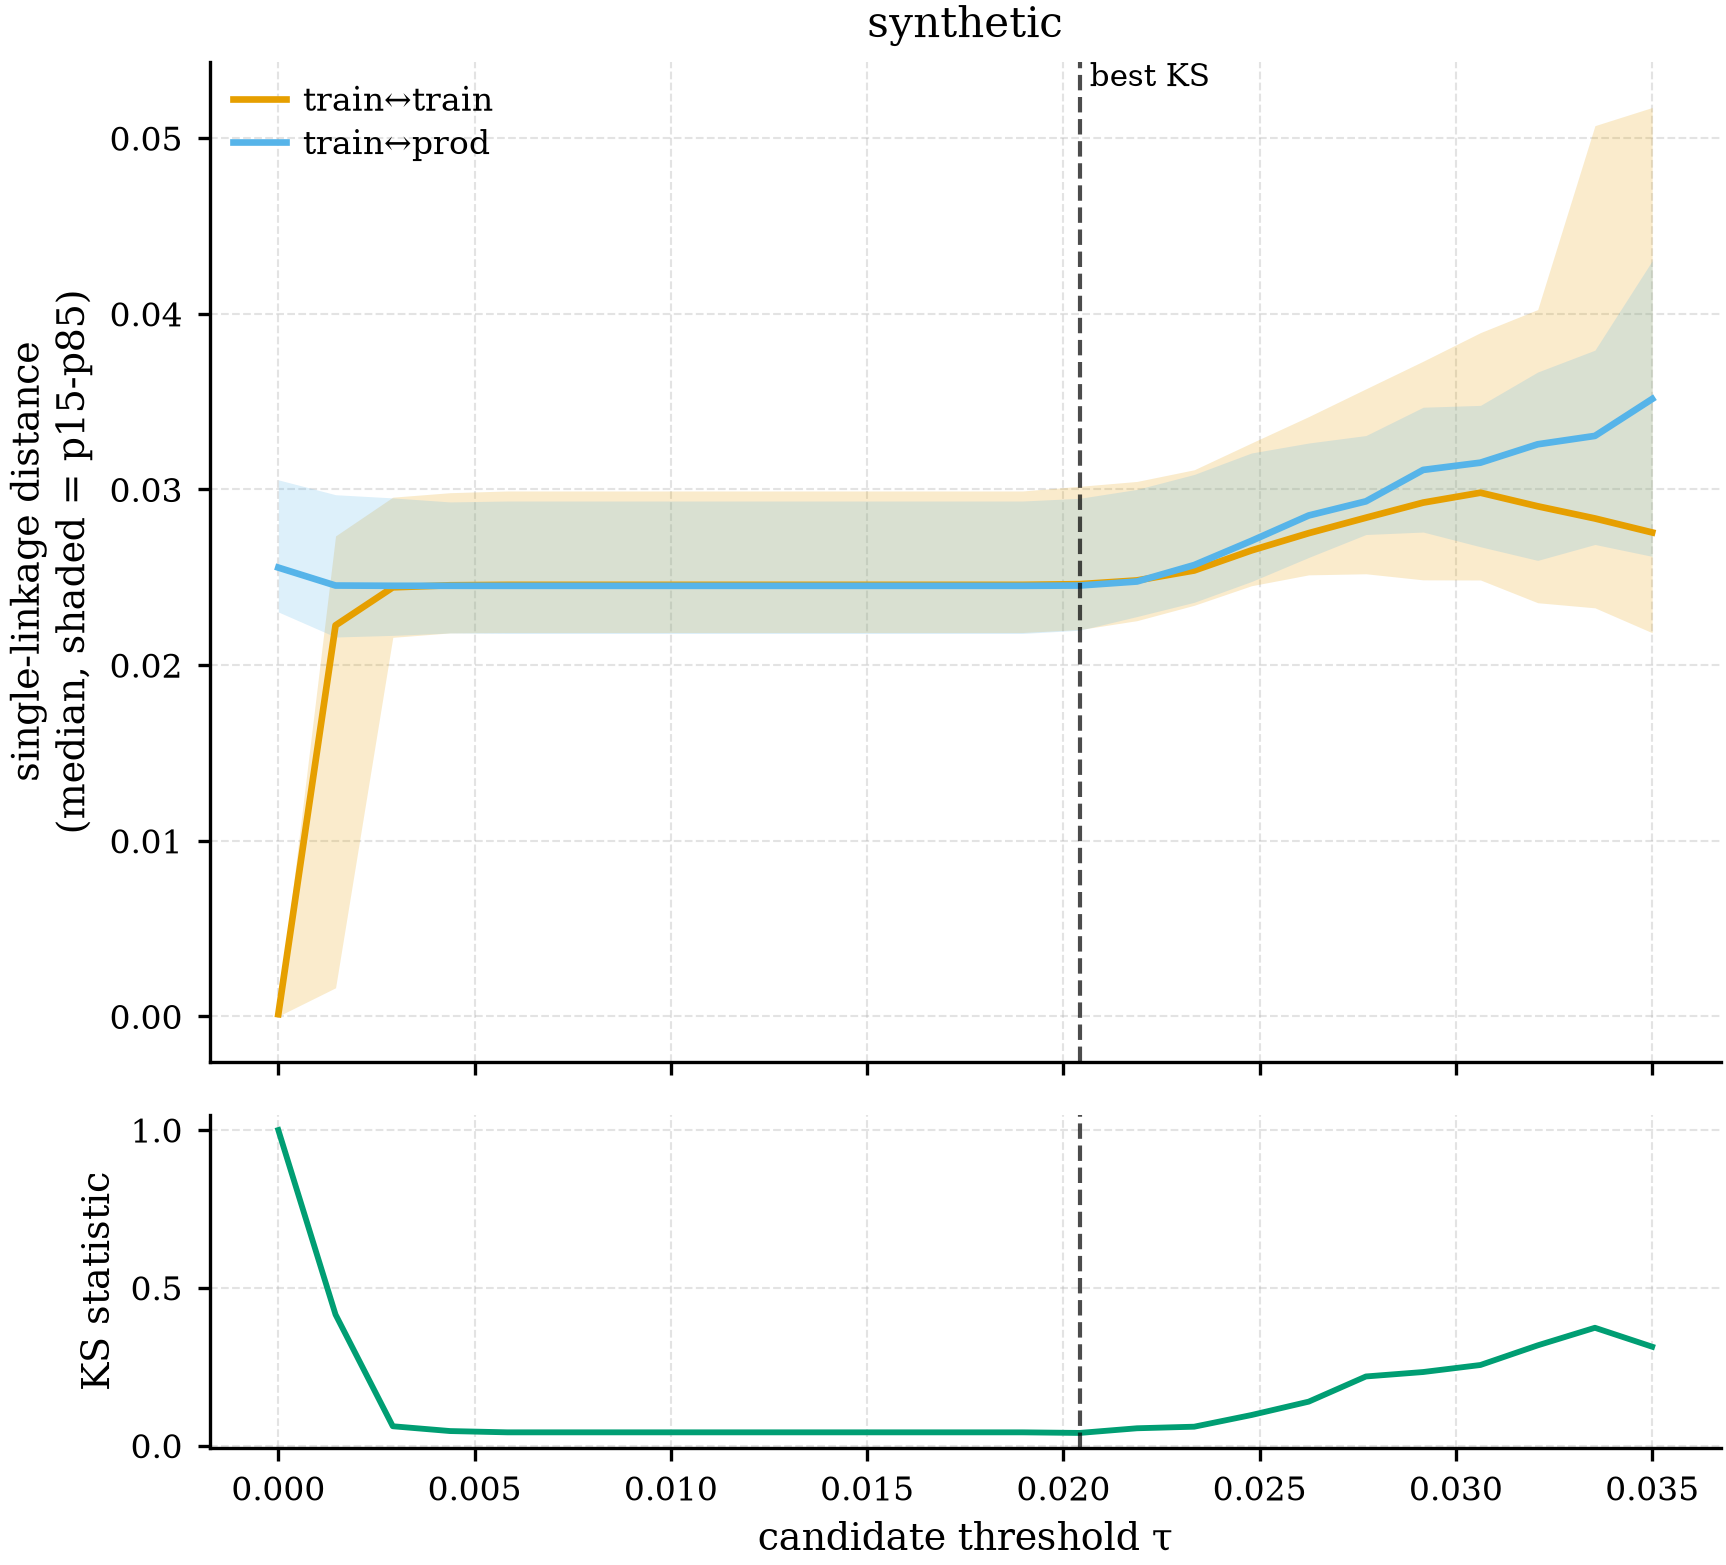

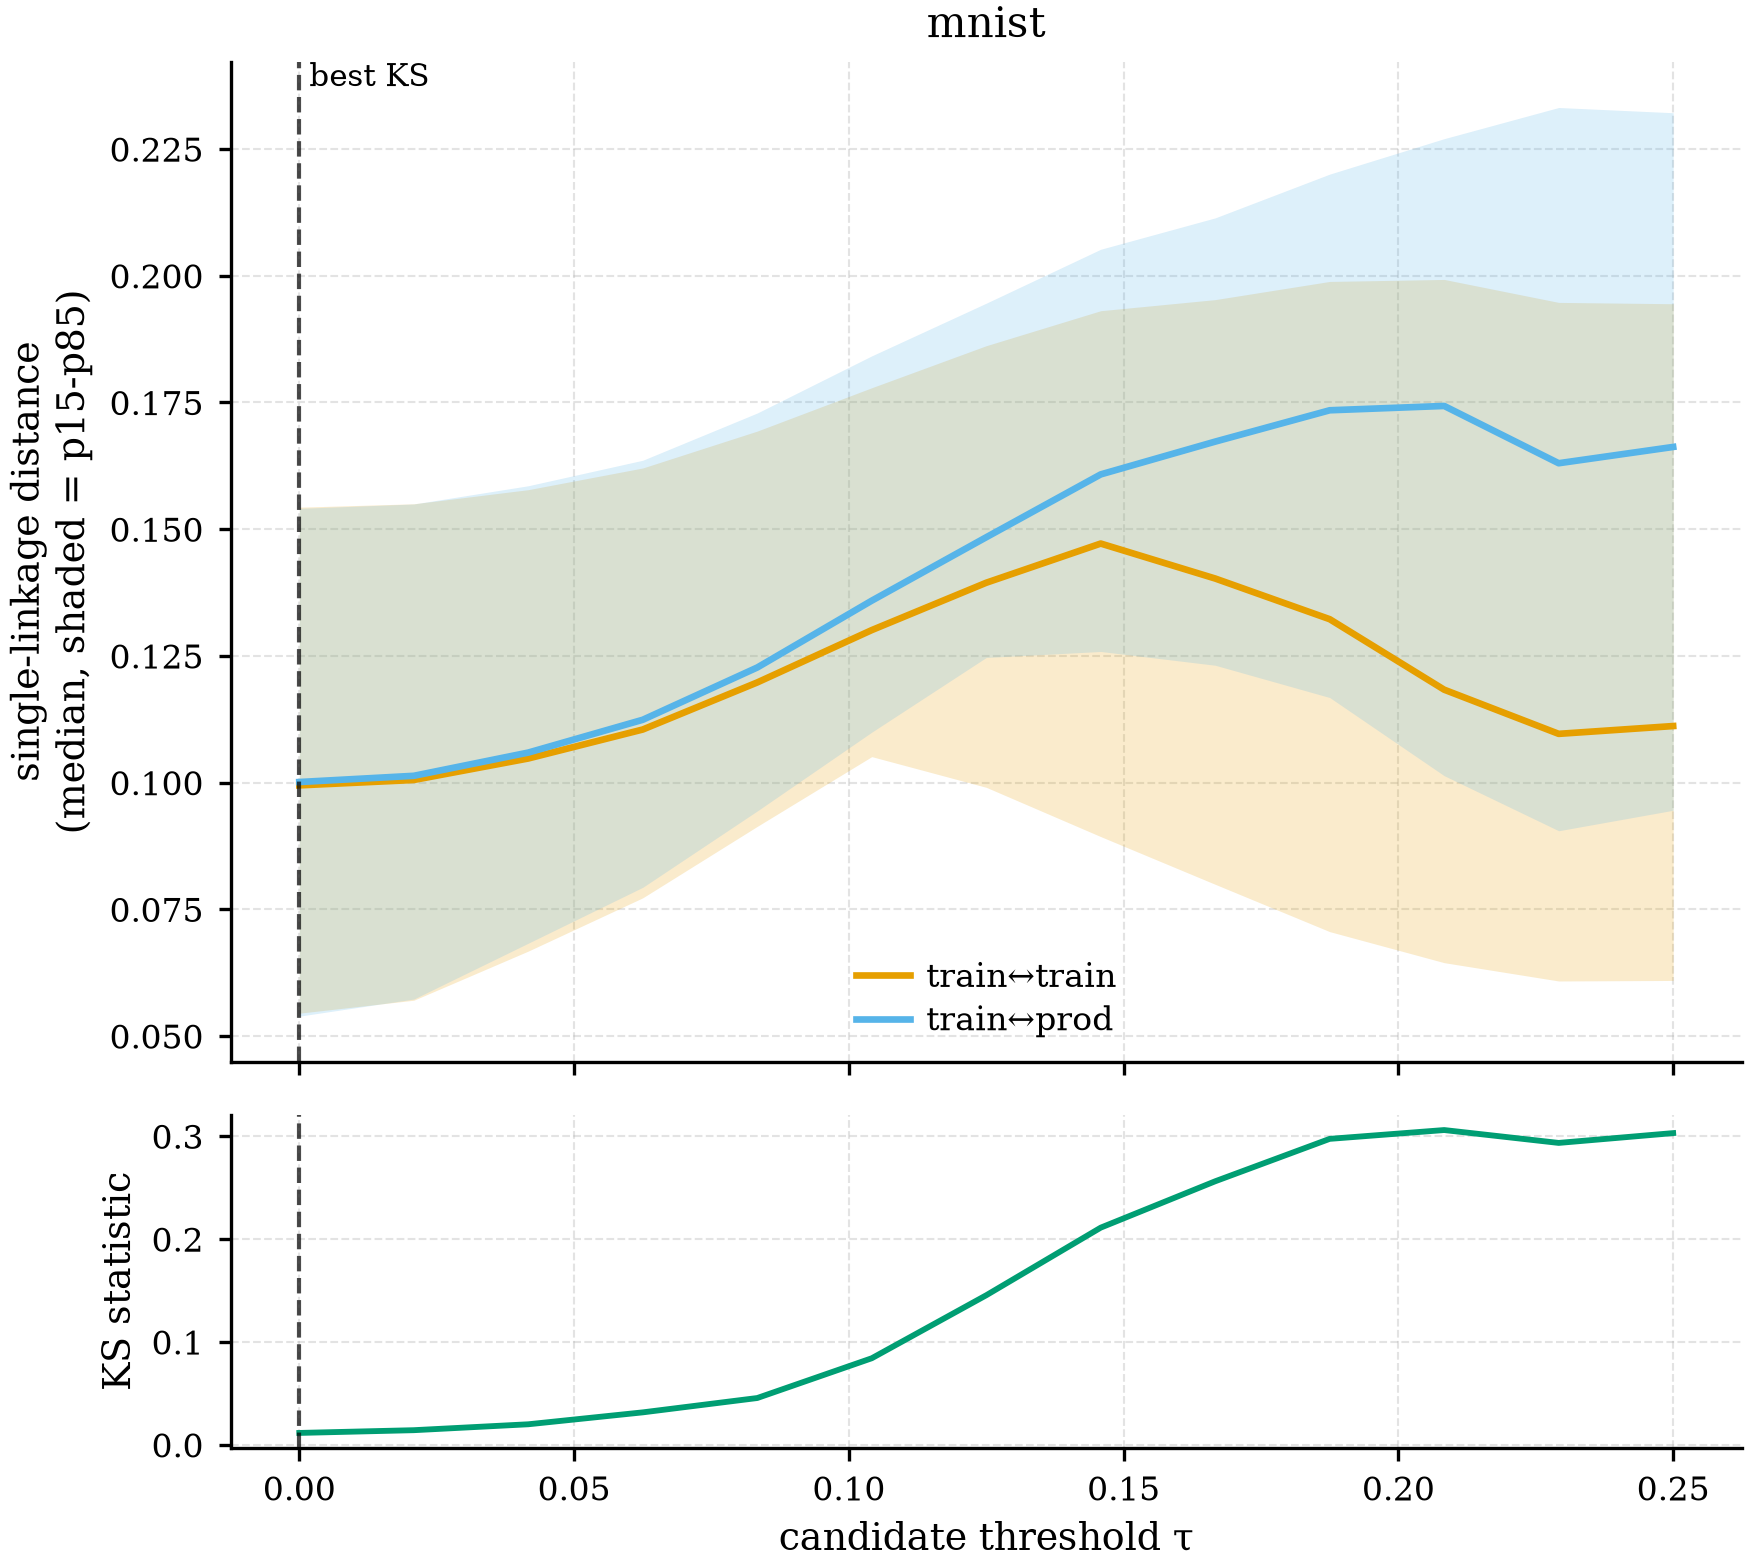

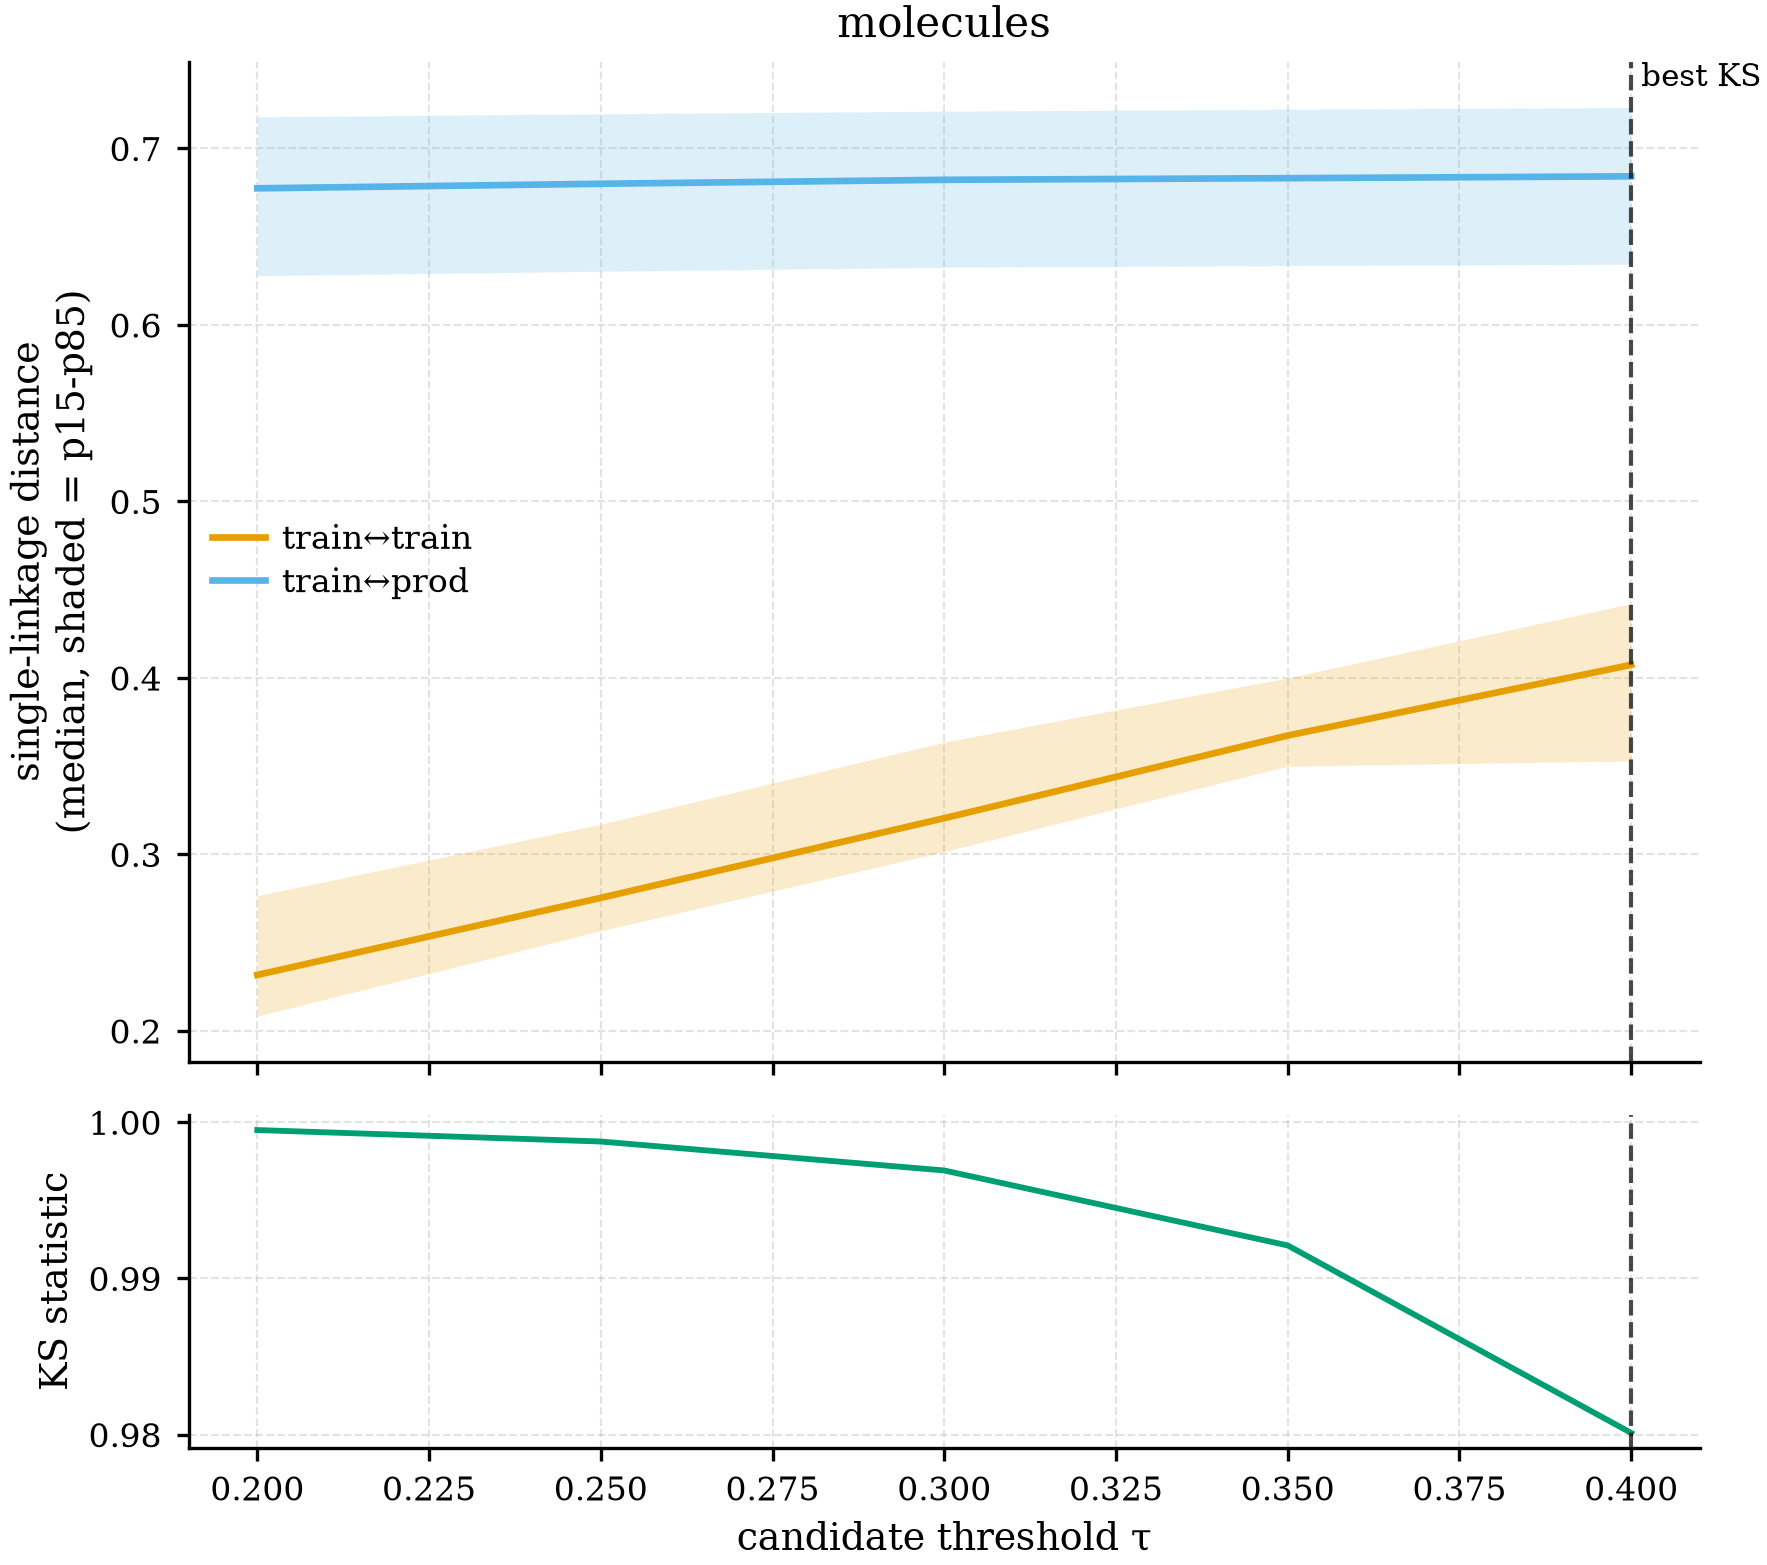

In [ ]:
# ---- Threshold section: train-train vs train-prod single-linkage distance ---
# distribution (median + p15-p85 spread) across candidate thresholds, with a
# shared-x panel underneath showing the KS statistic at each threshold.
# Handles both formats found under results/thresholds/: synthetic.json has
# top-level thresholds[]/best_threshold_ks; the rest (mnist/molecules/peptides/
# uniref.json) only have results[], each carrying its own "threshold" -- derive
# both from there.

THRESH_DIR = Path("..") / "results" / "thresholds"

def load_threshold_sweep(name: str) -> dict:
    with open(THRESH_DIR / f"{name}.json") as f:
        return json.load(f)

def plot_threshold_spread(name: str):
    d = load_threshold_sweep(name)
    results = sorted(d["results"], key=lambda r: r["threshold"])
    thresholds = np.array(d.get("thresholds", [r["threshold"] for r in results]))
    ks_stats = np.array([r["ks_stat"] for r in results])
    best_threshold_ks = d.get("Okay", float(thresholds[np.argmin(ks_stats)]))

    colors = method_colors(["refnd", "hestia"])
    ks_color = _cycle_colors[2]

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(6.5, 6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    )

    for key, label, color in (
        ("train_train", "train↔train", colors["refnd"]),
        ("train_prod", "train↔prod", colors["hestia"]),
    ):
        median = np.array([r[key]["median"] for r in results])
        p15 = np.array([r[key]["p15"] for r in results])
        p85 = np.array([r[key]["p85"] for r in results])
        ax_top.plot(thresholds, median, color=color, label=label)
        ax_top.fill_between(thresholds, p15, p85, color=color, alpha=0.2, linewidth=0)

    ax_top.axvline(best_threshold_ks, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax_top.text(best_threshold_ks, ax_top.get_ylim()[1], " best KS", fontsize=7.5, va="top", ha="left")
    ax_top.set_ylabel("single-linkage distance\n(median, shaded = p15-p85)")
    ax_top.set_title(f"{name}")
    ax_top.legend(fontsize=8)

    ax_bot.plot(thresholds, ks_stats, color=ks_color, linewidth=1.4)
    ax_bot.axvline(best_threshold_ks, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax_bot.set_ylabel("KS statistic")
    ax_bot.set_xlabel("candidate threshold τ")

    fig.tight_layout()
    return fig, (ax_top, ax_bot)

for dataset_name in ("synthetic", "mnist", "molecules", "peptides", "uniref"):
    fig, axes = plot_threshold_spread(dataset_name)
    plt.show()
    save_fig(fig, f"threshold_spread_{dataset_name}")

In [ ]:
# ---- uniref: real node-level ECDF, from threshold/uniref_investigation.py --
# Full nearest-train-neighbor distance ECDF (1000-level quantile function per
# group)
with open(THRESH_DIR / "unirefxbenchmark_ecdf.json") as f:
    ecdf_data = json.load(f)

def plot_ecdf_from_quantiles(d: dict):
    colors = method_colors(["refnd", "hestia"])
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for key, label, color in (
        ("train_train", "train↔train", colors["refnd"]),
        ("train_prod", "train↔prod", colors["hestia"]),
    ):
        q = d[key]
        ax.plot(q["values"], q["levels"], color=color,
               label=f"{label} (n={q['n_finite']:,}/{q['n_raw']:,})")

    ax.set_xlabel("nearest-train-neighbor distance")
    ax.set_ylabel("cumulative fraction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax

fig, ax = plot_ecdf_from_quantiles(ecdf_data)
plt.show()
save_fig(fig, "uniref_benchmark_ecdf")

In [ ]:
# ---- Table: percentile comparison, train<->train vs train<->prod -----------

PERCENTILES = [1, 5, 10, 25, 50, 75, 90, 95, 99]

def percentile_table(d: dict) -> pd.DataFrame:
    rows = []
    for p in PERCENTILES:
        level = p / 100.0
        tt = float(np.interp(level, d["train_train"]["levels"], d["train_train"]["values"]))
        tp = float(np.interp(level, d["train_prod"]["levels"], d["train_prod"]["values"]))
        rows.append({
            "percentile": p,
            "train↔train": tt,
            "train↔prod": tp,
            "prod - train": tp - tt,
        })
    return pd.DataFrame(rows)

pct_table = percentile_table(ecdf_data)
pct_table

/tmp/ipykernel_1751527/1688317384.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


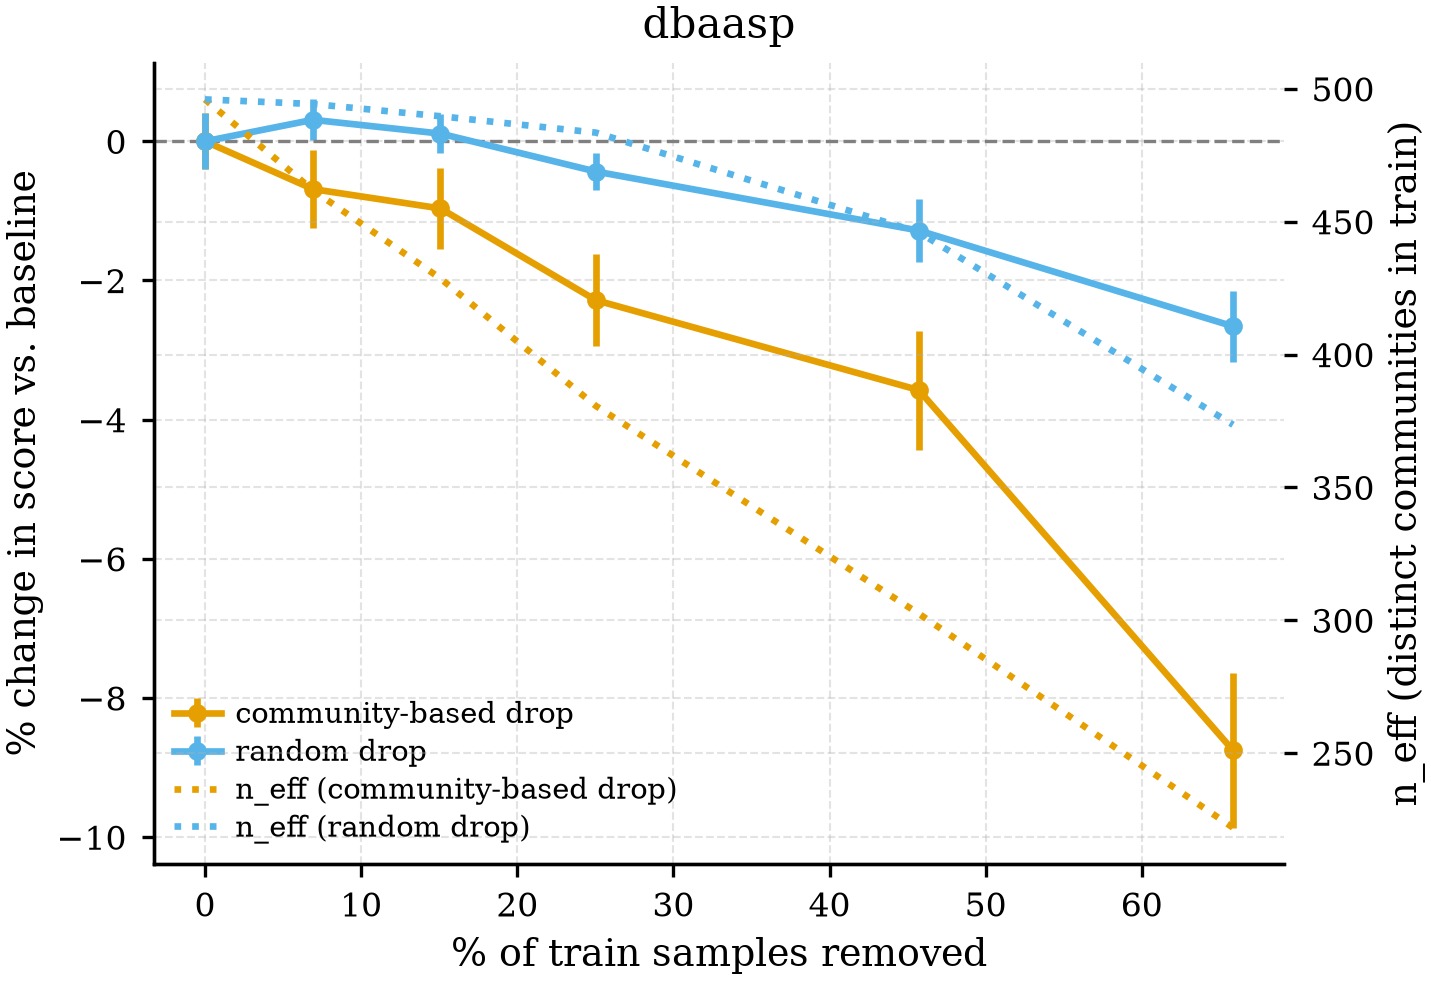

In [25]:
# ---- Data starvation: score vs. % of train samples removed -----------------
STARVE_DIR = Path("..") / "results" / "data_starvation"


def load_starvation(dataset: str) -> dict:
    with open(STARVE_DIR / f"{dataset}.json") as f:
        return json.load(f)


def plot_starvation(dataset: str):
    d = load_starvation(dataset)
    n_train = d["n_train"]
    by_frac = d["by_drop_fraction"]
    n_repeats = d["n_repeats"]

    drop_fracs = sorted(by_frac.keys(), key=float)
    pct_removed = [100.0 * by_frac[k]["n_dropped_mean"] / n_train for k in drop_fracs]

    baseline_key = min(drop_fracs, key=float)
    baseline = by_frac[baseline_key]["community_score_mean"]

    fig, ax = plt.subplots(figsize=(5, 3.5))
    score_lines = {}
    for key, label in [("community_score", "community-based drop"), ("random_score", "random drop")]:
        means = np.array([by_frac[k][f"{key}_mean"] for k in drop_fracs])
        stds = np.array([by_frac[k][f"{key}_std"] for k in drop_fracs])
        pct_change = 100.0 * (means - baseline) / baseline
        err = 100.0 * (stds / np.sqrt(n_repeats)) / baseline
        line = ax.errorbar(pct_removed, pct_change, yerr=err, marker="o", capsize=3, label=label)
        score_lines[key] = line[0].get_color()

    ax.axhline(0.0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("% of train samples removed")
    ax.set_ylabel("% change in score vs. baseline")

    ax_eff = ax.twinx()
    for key, label, color in [
        ("n_eff_community", "n_eff (community-based drop)", score_lines["community_score"]),
        ("n_eff_random", "n_eff (random drop)", score_lines["random_score"]),
    ]:
        n_eff = [by_frac[k][f"{key}_mean"] for k in drop_fracs]
        ax_eff.plot(pct_removed, n_eff, linestyle=":", marker="none", color=color, label=label)
    ax_eff.set_ylabel("n_eff (distinct communities in train)")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_eff.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7)

    ax.set_title(dataset)
    fig.tight_layout()
    return fig, (ax, ax_eff)


fig, axes = plot_starvation("dbaasp")
plt.show()
save_fig(fig, "data_starvation")